# S3 LST L2 data preparation
This script uses the downloaded Sentinel-3 data (for download see script `get_data_openeo_S3.ipynb`) for the lakes and preprocesses it:
- concatonates the years to one stack
- clips by -500m buffred shoreline of lake 6
- masks out cloud pixels
- calculates some statistics about the lake temperature:
    - mean, median, std, count the number of pixels used for it (this can be used for quality filtering later on), calculate bootstrapped confidence intervals etc, calculate the mean uncertainty (from the given uncertainty per pixel)
- this is then written into a csv file to disc for later use in the script called `data_analysis`

Note, that this is first done for one lake, and then in a loop for all the lakes for which data is within the folder (data for lake 6 is placed in a different folder called `data_2017_2025`).






In [21]:
# import modules
import pandas as pd
import geopandas as gpd
import numpy as np
import shapely as shp
import xarray as xr
import rasterio
import matplotlib.pyplot as plt
import cartopy
import glob
import os
import re
import rioxarray as rio

In [22]:
# get from the data folder all the lakes and months that exist
files = sorted(glob.glob("data/*.nc"))

lake_files = {}

pattern = re.compile(r"S3_LST_L2_(.+)_(\d{4})_(\d{2})\.nc$")

for file in files:
    filename = os.path.basename(file)

    match = pattern.match(filename)

    if match is None:
        print(f"Could not parse filename: {filename}")
        continue

    lake_id = match.group(1)

    lake_files.setdefault(lake_id, []).append(file)


print("Lakes found:")
for lake_id, files_for_lake in lake_files.items():
    print(f"{lake_id}: {len(files_for_lake)} files")

Lakes found:
lake_1: 116 files
lake_2: 9 files
lake_3: 116 files
lake_4: 117 files
lake_7: 116 files
lake_8: 117 files
lake_9: 116 files


In [23]:
###### This is the start for incorporating lake 6! ##############

# get from the data folder all the lakes and months that exist
files = sorted(glob.glob("data_2017_2025/*.nc"))


files_lake6 = sorted(glob.glob("data_2017_2025/*.nc"))

pattern_yearly = re.compile(
    r"S3_LST_L2_(.+)_(\d{4})\.nc$"
)

for file in files_lake6:
    filename = os.path.basename(file)

    match = pattern_yearly.match(filename)

    if match is None:
        print(f"Could not parse yearly filename: {filename}")
        continue

    lake_id = match.group(1)

    # Add the yearly files to the same dictionary
    lake_files.setdefault(lake_id, []).append(file)



In [24]:
# check all the lakes dir together (including lake 6) in one list
print("Lakes found:")

for lake_id, files_for_lake in lake_files.items():
    print(f"{lake_id}: {len(files_for_lake)} files")

    for f in files_for_lake:
        print("   ", f)
# everything there which also includes the

Lakes found:
lake_1: 116 files
    data\S3_LST_L2_lake_1_2016_04.nc
    data\S3_LST_L2_lake_1_2016_05.nc
    data\S3_LST_L2_lake_1_2016_06.nc
    data\S3_LST_L2_lake_1_2016_07.nc
    data\S3_LST_L2_lake_1_2016_08.nc
    data\S3_LST_L2_lake_1_2016_09.nc
    data\S3_LST_L2_lake_1_2016_10.nc
    data\S3_LST_L2_lake_1_2016_11.nc
    data\S3_LST_L2_lake_1_2016_12.nc
    data\S3_LST_L2_lake_1_2017_01.nc
    data\S3_LST_L2_lake_1_2017_02.nc
    data\S3_LST_L2_lake_1_2017_03.nc
    data\S3_LST_L2_lake_1_2017_04.nc
    data\S3_LST_L2_lake_1_2017_05.nc
    data\S3_LST_L2_lake_1_2017_06.nc
    data\S3_LST_L2_lake_1_2017_07.nc
    data\S3_LST_L2_lake_1_2017_08.nc
    data\S3_LST_L2_lake_1_2017_09.nc
    data\S3_LST_L2_lake_1_2017_10.nc
    data\S3_LST_L2_lake_1_2017_11.nc
    data\S3_LST_L2_lake_1_2017_12.nc
    data\S3_LST_L2_lake_1_2018_01.nc
    data\S3_LST_L2_lake_1_2018_02.nc
    data\S3_LST_L2_lake_1_2018_03.nc
    data\S3_LST_L2_lake_1_2018_04.nc
    data\S3_LST_L2_lake_1_2018_05.nc
    dat

lake_6


<positron-console-cell-25>:17: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.


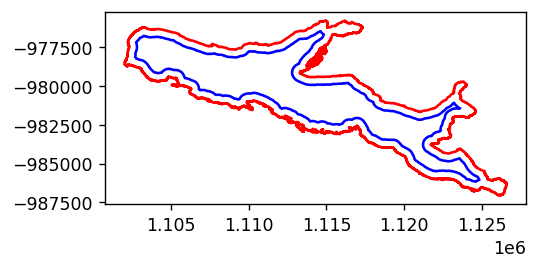

C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [25]:
# subset only one lake for the whole time, then perform everything just for this one lake first, then creating a loop
from unittest import skip
lake_file_key = list(lake_files.keys())[-1] # lake 9
print(lake_file_key)

# get the value/items of that key
lake_file_dirs = lake_files[lake_file_key]

# concat all the nc files along time dimesnion
datasets = [] # storage list

for file in lake_file_dirs:
    ds = xr.open_dataset(file, engine = "netcdf4")
    datasets.append(ds) # append 

#concat by time
data = xr.concat(datasets, dim = "t")

# make the xarray spatially aware by setting crs and x and y coords
data = data.rio.write_crs("EPSG:4326")  
data = data.rio.set_spatial_dims(x_dim="x", y_dim="y")  

# set lake id
lake_id = lake_file_key

lakes = gpd.read_file(r"../lake_polygons/largest_lakes_num_pixels.geojson")
lakes["lake_id"] = "lake_" + lakes["lake_id"].astype(str)
lake = lakes[lakes["lake_id"] == lake_id]

# change crs to define a buffer properly
lake_5938 = lake.to_crs(5938)

# shrink inward by 500 meters using a negative buffer
lake_5938_buffered = lake_5938.geometry.buffer(-500)
# reconvert to 4326
lake_buffered = lake_5938_buffered.to_crs(4326)

# quick check of buffer
fig, ax = plt.subplots(figsize = (10, 2))
lake_5938.boundary.plot(color = "red", ax = ax)
lake_5938_buffered.boundary.plot(color = "blue", ax = ax)
plt.show()

###### clip using buffered lake ########### 
data = data.rio.clip(lake_buffered.geometry, lake_buffered.crs, drop=True) # drop = True means that all NaN values (outside of lake are not stored any further)

### apply the cloud filtering to temp and unc bands
cloudy = (data["confidence_in"] >= 2**14) # int of 14bit
data["LST_c_filtered"] = data["LST"].where(~cloudy)
data["LST_uncertainty_c_filtered"] = data["LST_uncertainty"].where(~cloudy)

### descriptive stats: count_num_valid_pixels, median, mean, 

# count pixels per time step
counts_per_timestep = data["LST_c_filtered"].count(dim = ("x", "y"))

# calculate the temperature (mean/median of lake first)
mean = data["LST_c_filtered"].mean(("x", "y"))-273.15 # convert to celsius
median = data["LST_c_filtered"].median(("x", "y"))-273.15 # convert to celsius
uncertainty = data["LST_uncertainty_c_filtered"].mean(("x", "y"))
std = data["LST_c_filtered"].std(("x", "y"))

# make a proper pandas datetime object out of the median.t time dimension
data["t"] = pd.to_datetime(data["t"].values)

################### OPTIONL Bootstrapped CI ##############################
boot = False

# create empty NaN vectors in case boot is set to False
ci_lower = np.full(len(data.t), np.nan)
ci_upper = np.full(len(data.t), np.nan)

if boot:
    # flatten spatial dim into 1d array
    flat_data = data["LST_c_filtered"] - 273.15  
    flat_pixels = flat_data.stack(pixel=("x", "y"))

    # bootstrap pars and storage
    num_bootstraps = 1000  
    ci_lower = []
    ci_upper = []

    # loop through each timestap
    for tidx in range(len(flat_pixels.t)):
        # Get all pixel values for tidx, frop na
        timestep_pixels = flat_pixels.isel(t=tidx).values
        valid_pixels = timestep_pixels[~np.isnan(timestep_pixels)] # subset to get only valid pixels
        n_pixels = len(valid_pixels)
    
        # Handle edge cases (e.g., no data or too few pixels to bootstrap)
        if n_pixels < 5:  
            ci_lower.append(np.nan)
            ci_upper.append(np.nan)
            continue
        
        # make bootstrap samples with shape is (num_bootstraps, n_pixels)
        # pick at random with raplacement = T
        boot_samples = np.random.choice(valid_pixels, size=(num_bootstraps, n_pixels), replace=True)
    
        # compute median from bootstrap sample
        boot_medians = np.median(boot_samples, axis=1)
    
        # get 2.5 and 97.5t percentile
        ci_lower.append(np.percentile(boot_medians, 2.5))
        ci_upper.append(np.percentile(boot_medians, 97.5))

    # back into xarray 
    median = data["LST_c_filtered"].median(("x", "y")) - 273.15
    median["t"] = pd.to_datetime(median["t"].values) # put back

    # error bars relative to the median
    boot_err_lower = median.values - np.array(ci_lower)
    boot_err_upper = np.array(ci_upper) - median.values

    # into 2xN array for yerr par in plt.errorbar
    bootstrap_yerr = np.vstack([boot_err_lower, boot_err_upper])

# create pandas dataframe to store all the 
results_S3 = pd.DataFrame({
    "datetime": pd.to_datetime(median.t.values),
    "lst_median_C": median.values,
    "lst_mean_C": mean.values,
    "lst_mean_uncertainty": uncertainty.values,
    "lst_std":std.values,
    "bootstrap_ci_lower": ci_lower,
    "bootstrap_ci_upper": ci_upper,
    "n_valid_pixels": counts_per_timestep.values,
})

results_S3 = results_S3.set_index("datetime")


In [26]:
# write to csv file
results_S3.to_csv(f"data_processed/S3_LST_L2_{lake_id}.csv")

# do it in a loop for all lakes and years with data in the `data` folder

In [ ]:
print("Lakes found:")
for lake_id, files_for_lake in lake_files.items():
    print(f"{lake_id}: {len(files_for_lake)} files")

# great, also lake 6 is included!

Lakes found:
lake_1: 116 files
lake_2: 9 files
lake_3: 116 files
lake_4: 117 files
lake_7: 116 files
lake_8: 117 files
lake_9: 116 files
lake_6: 9 files


In [30]:
# define a function
def process_lake(lake_id, lake_file_dirs, lakes):
    
    #print some info
    print(f"\nProcessing {lake_id}...")
    print(f"Number of files: {len(lake_file_dirs)}")

    #storage to concat all files per lake (can become large)
    datasets = []

    for file in sorted(lake_file_dirs):
        ds = xr.open_dataset(file)
        datasets.append(ds)

    data = xr.concat(datasets, dim="t") # along time dim

    # make xarray sptially aware with crs and coords
    data = data.rio.write_crs("EPSG:4326")
    data = data.rio.set_spatial_dims(
        x_dim="x",
        y_dim="y"
    )

    # get the one lake for one looping round
    lake = lakes[lakes["lake_id"] == lake_id]

    if len(lake) == 0:
        raise ValueError(
            f"No shoreline found for {lake_id}")

    #buffer inward 500m to prevent edge effects, convert to UTM crs first, otherwise unit is wrong (needs to have meters not degrees)
    lake_5938 = lake.to_crs(5938)
    lake_5938_buffered = lake_5938.geometry.buffer(-500) # buffer
    lake_buffered = lake_5938_buffered.to_crs(4326) # reproject

    # clip by buffered shoreline of lake # important: this clips by central point of pixel, within shoreline
    data = data.rio.clip(
        lake_buffered.geometry,
        lake_buffered.crs,
        drop=True)

    # filter for clouds
    cloudy = data["confidence_in"] >= 2**14 # 14bit is clouds
    data["LST_c_filtered"] = data["LST"].where(~cloudy) # for temp
    data["LST_uncertainty_c_filtered"] = (data["LST_uncertainty"].where(~cloudy)) # for uncertainty

    # num valid pixels per time step (scene)
    counts_per_timestep = (
        data["LST_c_filtered"]
        .count(dim=("x", "y")))

    #extract stats
    mean = (data["LST_c_filtered"].mean(("x", "y"))- 273.15) # convert K->C
    median = (data["LST_c_filtered"].median(("x", "y"))- 273.15)
    uncertainty = (data["LST_uncertainty_c_filtered"].mean(("x", "y"))) # mean uncertainty
    std = (data["LST_c_filtered"].std(("x", "y")))
    #create datetime 
    data["t"] = pd.to_datetime(data["t"].values)

    ##########  OPTIONAL: Bootrapped CI ###############
    boot = False

    ci_lower = np.full(len(data.t), np.nan)
    ci_upper = np.full(len(data.t), np.nan)

    if boot:
        flat_data = (data["LST_c_filtered"] - 273.15)
        flat_pixels = flat_data.stack(pixel=("x", "y"))

        num_bootstraps = 1000

        ci_lower = []
        ci_upper = []

        for tidx in range(len(flat_pixels.t)):
            timestep_pixels = (
                flat_pixels
                .isel(t=tidx)
                .values)

            valid_pixels = timestep_pixels[
                ~np.isnan(timestep_pixels)]

            n_pixels = len(valid_pixels)

            if n_pixels < 5:
                ci_lower.append(np.nan)
                ci_upper.append(np.nan)
                continue

            boot_samples = np.random.choice(
                valid_pixels,
                size=(num_bootstraps, n_pixels),
                replace=True)

            boot_medians = np.median(boot_samples,axis=1)
            ci_lower.append(np.percentile(boot_medians, 2.5))
            ci_upper.append(np.percentile(boot_medians, 97.5))

        ci_lower = np.array(ci_lower)
        ci_upper = np.array(ci_upper)

    # --------------------------------------------------------
    # Create results dataframe
    # --------------------------------------------------------

    results = pd.DataFrame({
        "datetime": pd.to_datetime(median.t.values),
        "lst_median_C": median.values,
        "lst_mean_C": mean.values,
        "lst_mean_uncertainty": uncertainty.values,
        "lst_std": std.values,
        "bootstrap_ci_lower": ci_lower,
        "bootstrap_ci_upper": ci_upper,
        "n_valid_pixels": counts_per_timestep.values,
    })

    results = results.set_index("datetime")

    print(
        f"Finished {lake_id}: "
        f"{len(results)} timesteps"
    )

    return results

In [31]:
# run
lake_results = {}

for lake_id, lake_file_dirs in lake_files.items():

    lake_results[lake_id] = process_lake(
        lake_id,
        lake_file_dirs,
        lakes
    )


Processing lake_1...
Number of files: 116


<positron-console-cell-31>:15: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Finished lake_1: 48724 timesteps

Processing lake_2...
Number of files: 9


<positron-console-cell-31>:15: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Finished lake_2: 1562 timesteps

Processing lake_3...
Number of files: 116


...

Finished lake_8: 17782 timesteps

Processing lake_9...
Number of files: 116


<positron-console-cell-31>:15: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Finished lake_9: 26430 timesteps

Processing lake_6...
Number of files: 9


<positron-console-cell-31>:15: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Finished lake_6: 17085 timesteps


### write the values from the list to a csv file 

In [32]:
# write the data for each lake to a csv file and seperate folder called 'data_processed'
output_dir = "data_processed" # directory
os.makedirs(output_dir, exist_ok=True)

for lake_id, results in lake_results.items():
    filepath = os.path.join(
        output_dir,
        f"S3_LST_L2_{lake_id}.csv"
    )

    results.to_csv(filepath, index=True)

    print(f"Saved {lake_id}: {filepath}")

Saved lake_1: data_processed\S3_LST_L2_lake_1.csv
Saved lake_2: data_processed\S3_LST_L2_lake_2.csv
Saved lake_3: data_processed\S3_LST_L2_lake_3.csv
Saved lake_4: data_processed\S3_LST_L2_lake_4.csv
Saved lake_7: data_processed\S3_LST_L2_lake_7.csv
Saved lake_8: data_processed\S3_LST_L2_lake_8.csv
Saved lake_9: data_processed\S3_LST_L2_lake_9.csv
Saved lake_6: data_processed\S3_LST_L2_lake_6.csv
